# Data Cleaning & Feature Engineering

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_data

In [2]:
df= load_data('data\\bankruptcy.csv')
print(df.shape)
df.head()

(6819, 95)


,Bankrupt,ROA_C_Before_Interest_Depreciation,ROA_A_Before_Interest_After_Tax,ROA_B_Before_Interest_Depreciation_After_Tax,Operating_Gross_Margin,Realized_Sales_Gross_Margin,Operating_Profit_Rate,PreTax_Net_Interest_Rate,AfterTax_Net_Interest_Rate,NonIndustry_Income_Expenditure_Revenue,...,Liability_Assets_Flag,Net_Income_to_Total_Assets,Total_Assets_to_GNP_Price,NoCredit_Interval,Gross_Profit_to_Sales,Net_Income_to_Stockholders_Equity,Liability_to_Equity,DFL,Interest_Coverage_Ratio,Equity_to_Liability
0,0,0.571832,0.642390,0.634670,0.626169,0.626169,0.999232,0.797749,0.809653,0.303602,...,0,0.854406,0.007801,0.623980,0.626165,0.843256,0.275994,0.026797,0.565185,0.083956
1,0,0.494613,0.549771,0.543445,0.602091,0.602091,0.998986,0.797405,0.809328,0.303516,...,0,0.804106,0.007002,0.623701,0.602091,0.840783,0.281189,0.027200,0.566564,0.025107
2,0,0.465315,0.515645,0.511591,0.593782,0.593782,0.998961,0.797354,0.809277,0.303480,...,0,0.785955,0.008955,0.623801,0.593777,0.839341,0.278153,0.026630,0.564252,0.038119
3,0,0.506118,0.556912,0.547727,0.615820,0.615820,0.999169,0.797528,0.809401,0.303348,...,0,0.810229,0.000662,0.623844,0.615818,0.840996,0.277714,0.026863,0.565477,0.042154
4,0,0.539170,0.593273,0.586273,0.606949,0.606949,0.999077,0.797485,0.809394,0.303465,...,0,0.827668,0.001374,0.623774,0.606948,0.842516,0.279316,0.026818,0.565285,0.031117


## Handle Missing Values

In [3]:
missing = df.isnull().sum().sum()

missing_df = pd.DataFrame({'Feature': ['Missing'], 'Amount': [missing]})
missing_df  

,Feature,Amount
0,Missing,0


## Clipping the dataset to quantile 

In [4]:
def cap_outlier(df , upper = 0.995, lower =0.005):
    df = df.copy()
    
    num = df.select_dtypes(include= [np.number]).columns
    
    for col in num:
        lo, hi = df[col].quantile([lower, upper])
        df[col] = df[col].clip(lo, hi) 
    
    return df

In [5]:
df_clean = cap_outlier(df , upper = 0.995, lower =0.005)

print('NaN count:', df_clean.isnull().sum().sum())
df_imputed = df_clean.copy()

NaN count: 0


## Display before and after Imputation

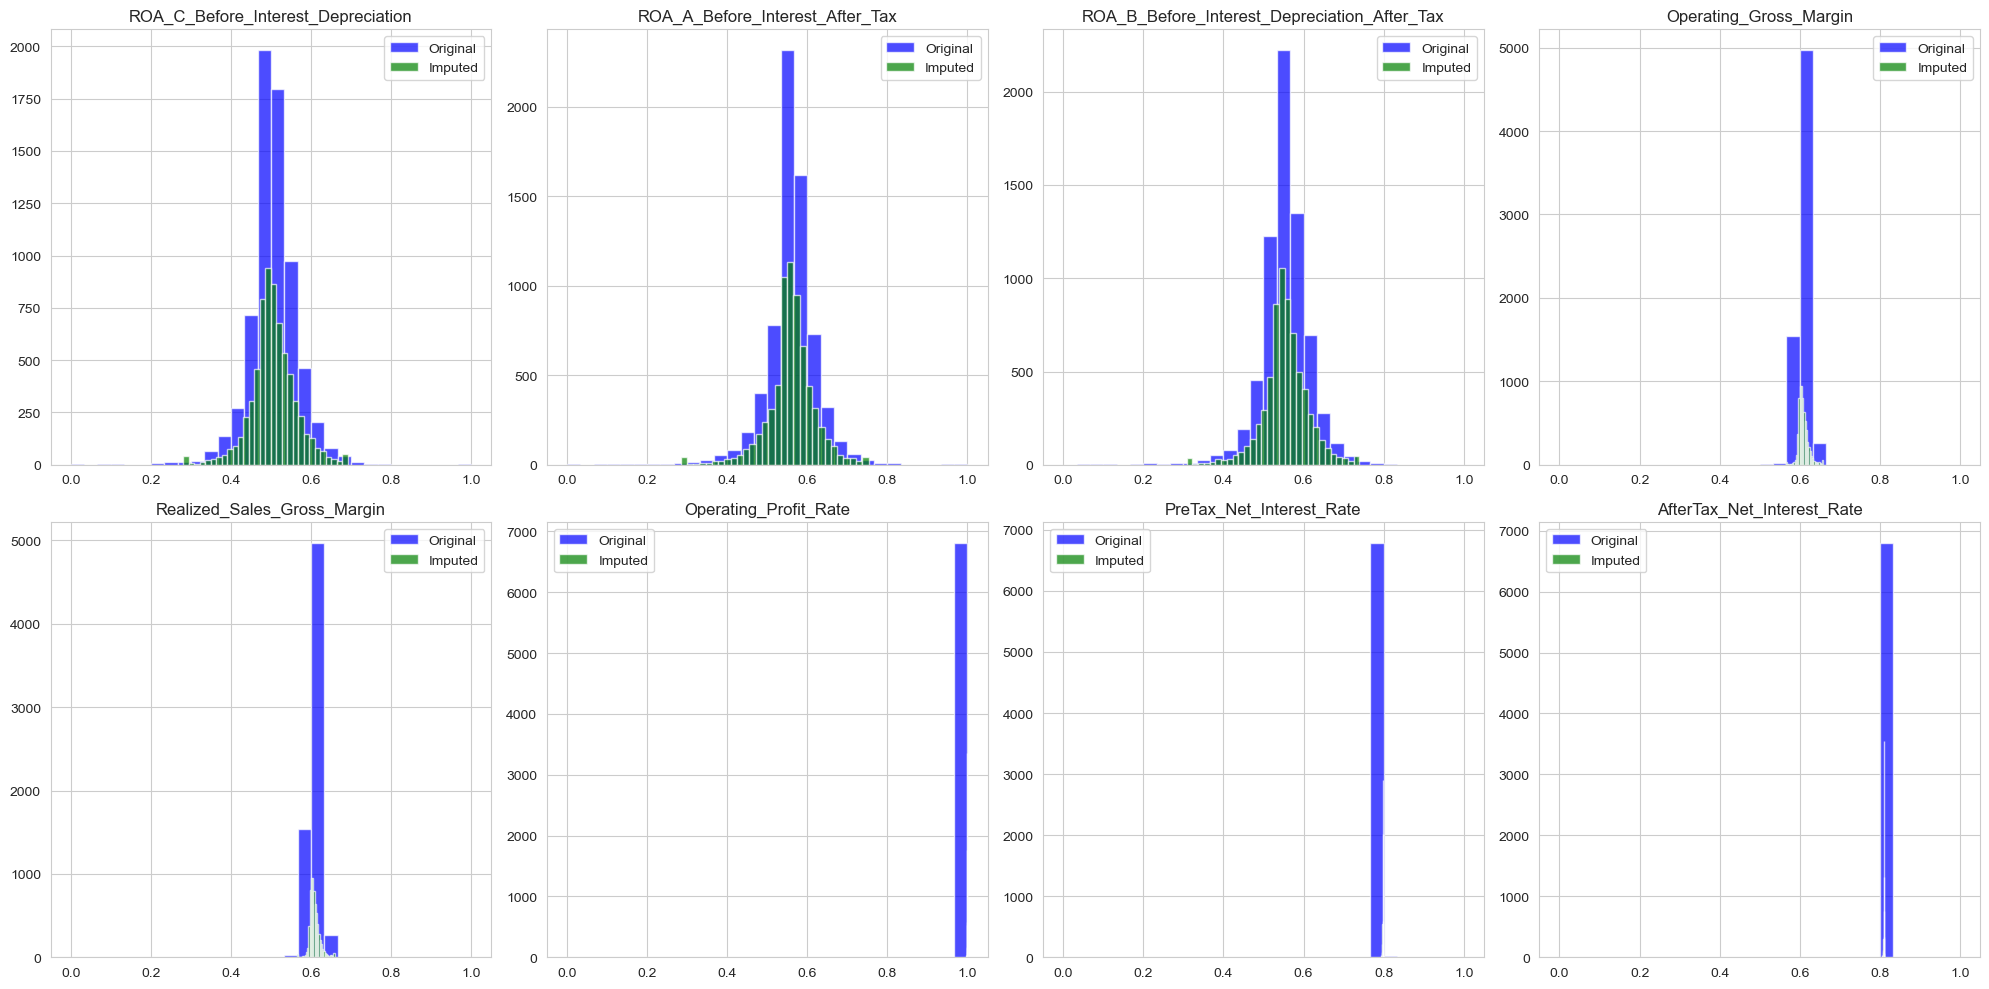

In [6]:
fig, axes = plt.subplots(2, 4 , figsize =(20, 10))

org_num = df.drop("Bankrupt", axis=1).select_dtypes(include= [np.number]).columns[:8].tolist()
imp_num = df_imputed.drop("Bankrupt", axis=1).select_dtypes(include= [np.number]).columns[:8].tolist()

axes = axes.flatten()
for i, col in enumerate([org_num, imp_num]):
    for j, c in enumerate(col):
        if i == 0:
            axes[j].hist(df[c], bins=30, color='blue', alpha=0.7, label='Original')
            axes[j].set_title(f'{c}')
        else:
            axes[j].hist(df_imputed[c], bins=30, color='green', alpha=0.7, label='Imputed')
            axes[j].set_title(f'{c}')
        axes[j].legend()
plt.tight_layout();     plt.show()

## Feature Engineering 

In [12]:
def create_feature(df):
    df = df.copy()
    
    profit = [c for c in df.columns if any(x in c for x in ['ROA', 'ROE', 'Operating_Profit_Margin', 'Net_Profit_Margin'])]
    leverage = [c for c in df.columns if any(x in c for x in ['Liability', 'Debt', 'Borrowing'])]
    liquidity = [c for c in df.columns if any(x in c for x in ['Quick_Ratio', 'Current_Ratio', 'Cash'])] 
    
    if profit:
        df['Profitability'] = df[profit].mean(axis= 1)
    if leverage :
        df['Leverage'] = df[leverage].mean(axis= 1)
    if liquidity:
        df['liquidity'] = df[liquidity].mean(axis= 1)
        
    
    return df

In [13]:
df_feat = create_feature(df_imputed)
print(df_feat.shape)
df_feat.head()

(6819, 98)


,Bankrupt,ROA_C_Before_Interest_Depreciation,ROA_A_Before_Interest_After_Tax,ROA_B_Before_Interest_Depreciation_After_Tax,Operating_Gross_Margin,Realized_Sales_Gross_Margin,Operating_Profit_Rate,PreTax_Net_Interest_Rate,AfterTax_Net_Interest_Rate,NonIndustry_Income_Expenditure_Revenue,...,NoCredit_Interval,Gross_Profit_to_Sales,Net_Income_to_Stockholders_Equity,Liability_to_Equity,DFL,Interest_Coverage_Ratio,Equity_to_Liability,Profitability,Leverage,liquidity
0,0,0.571832,0.642390,0.634670,0.626169,0.626169,0.999232,0.797749,0.809653,0.303602,...,0.623980,0.626165,0.843256,0.275994,0.026797,0.565185,0.083956,0.616297,2.163525e-01,2.891064e-01
1,0,0.494613,0.549771,0.543445,0.602091,0.602091,0.998986,0.797405,0.809328,0.303516,...,0.623701,0.602091,0.840783,0.281189,0.027200,0.566564,0.025107,0.529276,1.836842e+08,3.250000e+08
2,0,0.465315,0.515645,0.511591,0.593782,0.593782,0.998961,0.797354,0.809277,0.303480,...,0.623801,0.593777,0.839341,0.278153,0.026630,0.564252,0.038119,0.497517,2.007148e-01,2.966667e+08
3,0,0.506118,0.556912,0.547727,0.615820,0.615820,0.999169,0.797528,0.809401,0.303348,...,0.623844,0.615818,0.840996,0.277714,0.026863,0.565477,0.042154,0.536919,1.923942e-01,2.828956e-01
4,0,0.539170,0.593273,0.586273,0.606949,0.606949,0.999077,0.797485,0.809394,0.303465,...,0.623774,0.606948,0.842516,0.279316,0.026818,0.565285,0.031117,0.572906,2.198472e-01,5.433333e+08


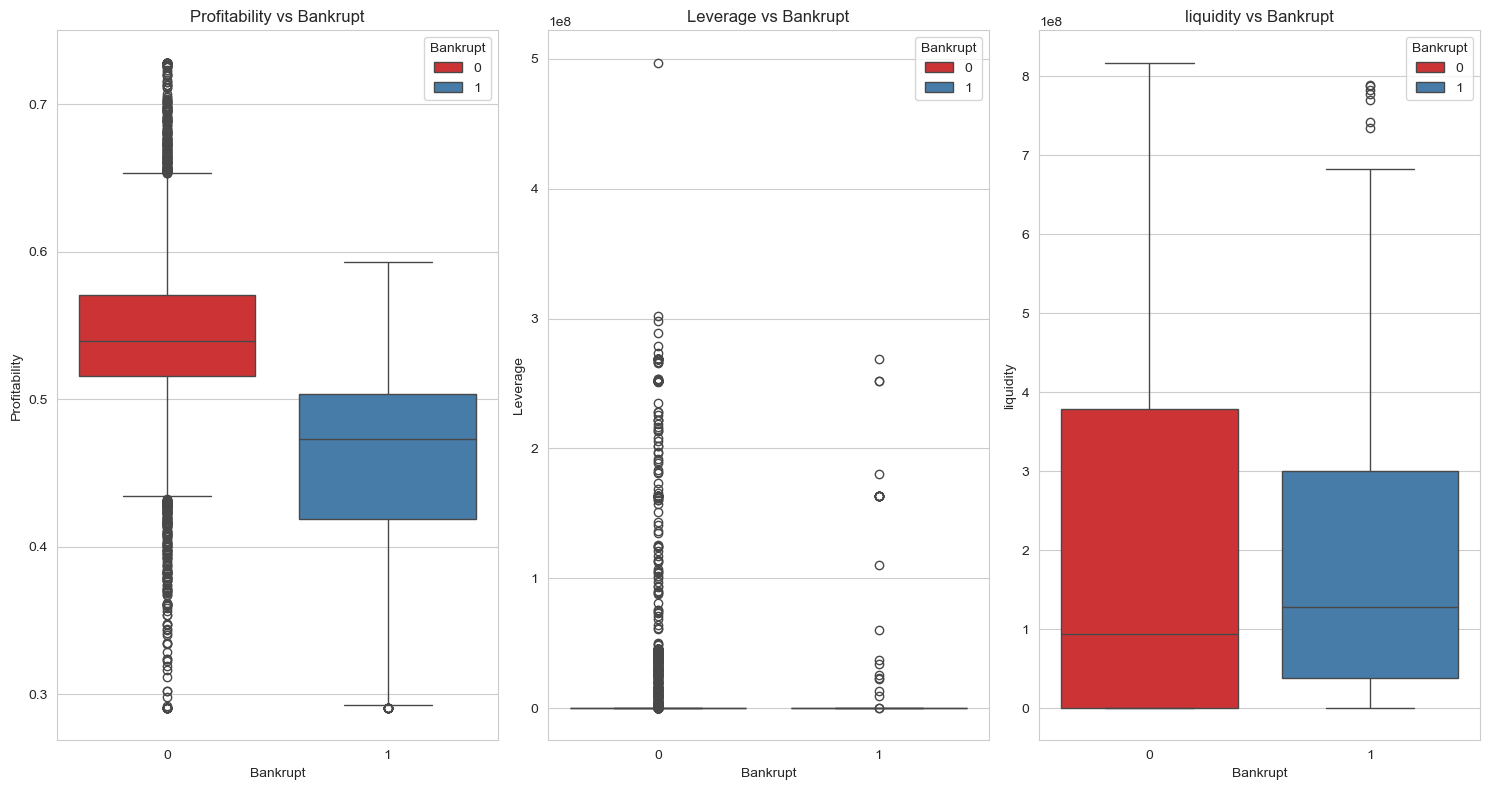

In [16]:
agg_feat = [c for c in ['Profitability', 'Leverage', 'liquidity'] if c in df_feat.columns]


fig, axes = plt.subplots(1,len(agg_feat) , figsize =(5 * len(agg_feat), 8))
for i, c in enumerate(agg_feat):
    sns.boxplot(x='Bankrupt', y= c, data= df_feat,ax=axes[i], palette="Set1", hue='Bankrupt' )
    axes[i].set_title(f"{c} vs Bankrupt")

plt.tight_layout(); plt.show()



## Encode Categorical Data

No categorical columns

# Save the Cleaned Dataset 

In [25]:
df_feat.to_csv('data\\cleaned_bankrupty.csv', index=False)
print('Saved to --> data\\cleaned_bankrupty.cs')

df_feat.head()

Saved to --> data\cleaned_bankrupty.cs


,Bankrupt,ROA_C_Before_Interest_Depreciation,ROA_A_Before_Interest_After_Tax,ROA_B_Before_Interest_Depreciation_After_Tax,Operating_Gross_Margin,Realized_Sales_Gross_Margin,Operating_Profit_Rate,PreTax_Net_Interest_Rate,AfterTax_Net_Interest_Rate,NonIndustry_Income_Expenditure_Revenue,...,NoCredit_Interval,Gross_Profit_to_Sales,Net_Income_to_Stockholders_Equity,Liability_to_Equity,DFL,Interest_Coverage_Ratio,Equity_to_Liability,Profitability,Leverage,liquidity
0,0,0.571832,0.642390,0.634670,0.626169,0.626169,0.999232,0.797749,0.809653,0.303602,...,0.623980,0.626165,0.843256,0.275994,0.026797,0.565185,0.083956,0.616297,2.163525e-01,2.891064e-01
1,0,0.494613,0.549771,0.543445,0.602091,0.602091,0.998986,0.797405,0.809328,0.303516,...,0.623701,0.602091,0.840783,0.281189,0.027200,0.566564,0.025107,0.529276,1.836842e+08,3.250000e+08
2,0,0.465315,0.515645,0.511591,0.593782,0.593782,0.998961,0.797354,0.809277,0.303480,...,0.623801,0.593777,0.839341,0.278153,0.026630,0.564252,0.038119,0.497517,2.007148e-01,2.966667e+08
3,0,0.506118,0.556912,0.547727,0.615820,0.615820,0.999169,0.797528,0.809401,0.303348,...,0.623844,0.615818,0.840996,0.277714,0.026863,0.565477,0.042154,0.536919,1.923942e-01,2.828956e-01
4,0,0.539170,0.593273,0.586273,0.606949,0.606949,0.999077,0.797485,0.809394,0.303465,...,0.623774,0.606948,0.842516,0.279316,0.026818,0.565285,0.031117,0.572906,2.198472e-01,5.433333e+08
